Regional Sales Analysis Project (Using Jupyter Extension in VS Code)
- Import all relevant libraries
- Ensure path is correct for the Regional Sales Analysis .xlsx file

In [2362]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2363]:
# Check if the Excel file exists
os.path.exists('RegionalSalesDataset.xlsx')

True

Load the Regional Sales Analysis Datasheet 
- Ensure Pandas is referenced
- Print the individual sheet names as a check
- Break Datasheet down by sheet and load 
- Print header of each to do a check 

In [2364]:
# Load the Excel file
excel_file = pd.ExcelFile('RegionalSalesDataset.xlsx')

In [2365]:
# Load each sheet into a separate DataFrame
df_SalesOrders = pd.read_excel(excel_file, sheet_name='Sales Orders')
df_Customers = pd.read_excel(excel_file, sheet_name='Customers')
df_Regions = pd.read_excel(excel_file, sheet_name='Regions')
df_StateRegions = pd.read_excel(excel_file, sheet_name='State Regions')
df_Products = pd.read_excel(excel_file, sheet_name='Products')
df_2017_Budgets = pd.read_excel(excel_file, sheet_name='2017 Budgets')

In [2366]:
df_SalesOrders.head(2)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918


In [2367]:
df_Customers.head(2)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group


In [2368]:
df_Regions.head(2)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago


In [2369]:
df_StateRegions.head(2) 

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South


In [2370]:
df_Products.head(2)

,Index,Product Name
0,1,Product 1
1,2,Product 2


In [2371]:
df_2017_Budgets.head(2) 

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565


Clean All Data 
- Ensure no null values 
- Ensure data types are in line for creating graphs
- Drop all unnecessary data
- Merge all data into one excel file for plotting ease 


In [2372]:
# Drop unnecessary columns
df_SalesOrders.drop(['OrderNumber', 'Currency Code', 'Warehouse Code'], axis=1, inplace=True)

In [2373]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderDate                  64104 non-null  datetime64[ns]
 1   Customer Name Index        64104 non-null  int64         
 2   Channel                    64104 non-null  object        
 3   Delivery Region Index      64104 non-null  int64         
 4   Product Description Index  64104 non-null  int64         
 5   Order Quantity             64104 non-null  int64         
 6   Unit Price                 64104 non-null  float64       
 7   Line Total                 64104 non-null  float64       
 8   Total Unit Cost            64104 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(1)
memory usage: 4.4+ MB


In [2374]:
df_Customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Customer Index  175 non-null    int64 
 1   Customer Names  175 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.9+ KB


In [2375]:
df_Regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             994 non-null    int64  
 1   name           994 non-null    object 
 2   county         994 non-null    object 
 3   state_code     994 non-null    object 
 4   state          994 non-null    object 
 5   type           994 non-null    object 
 6   latitude       994 non-null    float64
 7   longitude      994 non-null    float64
 8   area_code      994 non-null    int64  
 9   population     994 non-null    int64  
 10  households     994 non-null    int64  
 11  median_income  994 non-null    int64  
 12  land_area      994 non-null    int64  
 13  water_area     994 non-null    int64  
 14  time_zone      994 non-null    object 
dtypes: float64(2), int64(7), object(6)
memory usage: 116.6+ KB


In [2376]:
# Remove unnecessary columns
df_Regions.drop(['county', 'type', 'latitude', 'longitude', 'area_code', 'population', 'households', 'median_income', 'land_area', 'water_area', 'time_zone'], axis=1, inplace=True)

In [2377]:
df_Regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          994 non-null    int64 
 1   name        994 non-null    object
 2   state_code  994 non-null    object
 3   state       994 non-null    object
dtypes: int64(1), object(3)
memory usage: 31.2+ KB


In [2378]:
df_StateRegions.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Column1  49 non-null     object
 1   Column2  49 non-null     object
 2   Column3  49 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


In [2379]:
# Remove the first row if it contains redundant header information
df_StateRegions = df_StateRegions.drop(df_StateRegions.index[0]).reset_index(drop=True)

In [2380]:
# Rename columns for clarity
df_StateRegions.columns = ['State Code', 'State', 'Region']

In [2381]:
df_StateRegions.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   State Code  48 non-null     object
 1   State       48 non-null     object
 2   Region      48 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


In [2382]:
df_Products.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Index         30 non-null     int64 
 1   Product Name  30 non-null     object
dtypes: int64(1), object(1)
memory usage: 612.0+ bytes


In [2383]:
df_2017_Budgets.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product Name  30 non-null     object 
 1   2017 Budgets  30 non-null     float64
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes


In [2384]:
# Merge DataFrames
df_SalesOrders = df_SalesOrders.merge(df_Customers, left_on='Customer Name Index', right_on='Customer Index', how='left')

In [2385]:
# Remove redundant columns after merge
df_SalesOrders.drop(['Customer Name Index', 'Customer Index'], axis=1, inplace=True)

In [2386]:
# Rename column for clarity
df_SalesOrders.rename(columns={'Customer Names': 'Customer Name'}, inplace=True)

In [2387]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderDate                  64104 non-null  datetime64[ns]
 1   Channel                    64104 non-null  object        
 2   Delivery Region Index      64104 non-null  int64         
 3   Product Description Index  64104 non-null  int64         
 4   Order Quantity             64104 non-null  int64         
 5   Unit Price                 64104 non-null  float64       
 6   Line Total                 64104 non-null  float64       
 7   Total Unit Cost            64104 non-null  float64       
 8   Customer Name              64104 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 4.4+ MB


In [2388]:
# Merge with Regions DataFrame
df_SalesOrders = df_SalesOrders.merge(df_Regions[['id', 'name', 'state_code', 'state']], left_on='Delivery Region Index', right_on='id', how='left')

In [2389]:
# Remove redundant columns after merge
df_SalesOrders.drop(['Delivery Region Index', 'id'], axis=1, inplace=True)

In [2390]:
# Rename columns for clarity
df_SalesOrders.rename(columns={'name': 'City', 'state_code': 'State Code', 'state': 'State', 'median_income': 'Median Income'}, inplace=True)

In [2391]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderDate                  64104 non-null  datetime64[ns]
 1   Channel                    64104 non-null  object        
 2   Product Description Index  64104 non-null  int64         
 3   Order Quantity             64104 non-null  int64         
 4   Unit Price                 64104 non-null  float64       
 5   Line Total                 64104 non-null  float64       
 6   Total Unit Cost            64104 non-null  float64       
 7   Customer Name              64104 non-null  object        
 8   City                       64104 non-null  object        
 9   State Code                 64104 non-null  object        
 10  State                      64104 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage:

In [2392]:
# Merge with Products DataFrame
df_SalesOrders = df_SalesOrders.merge(df_Products, left_on='Product Description Index', right_on='Index', how='left')

In [2393]:
# Remove redundant columns after merge
df_SalesOrders.drop(['Product Description Index', 'Index'], axis=1, inplace=True)

In [2394]:
# Rename column for clarity
df_SalesOrders.rename(columns={'Product Name': 'Product (SKU)'}, inplace=True)

In [2395]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderDate        64104 non-null  datetime64[ns]
 1   Channel          64104 non-null  object        
 2   Order Quantity   64104 non-null  int64         
 3   Unit Price       64104 non-null  float64       
 4   Line Total       64104 non-null  float64       
 5   Total Unit Cost  64104 non-null  float64       
 6   Customer Name    64104 non-null  object        
 7   City             64104 non-null  object        
 8   State Code       64104 non-null  object        
 9   State            64104 non-null  object        
 10  Product (SKU)    64104 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(6)
memory usage: 5.4+ MB


In [2396]:
# Merge with StateRegions DataFrame
df_SalesOrders = df_SalesOrders.merge(df_StateRegions[['State Code', 'Region']], on='State Code', how='left')

In [2397]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderDate        64104 non-null  datetime64[ns]
 1   Channel          64104 non-null  object        
 2   Order Quantity   64104 non-null  int64         
 3   Unit Price       64104 non-null  float64       
 4   Line Total       64104 non-null  float64       
 5   Total Unit Cost  64104 non-null  float64       
 6   Customer Name    64104 non-null  object        
 7   City             64104 non-null  object        
 8   State Code       64104 non-null  object        
 9   State            64104 non-null  object        
 10  Product (SKU)    64104 non-null  object        
 11  Region           64104 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 5.9+ MB


In [2398]:
# Merge with 2017 Budgets DataFrame
df_SalesOrders = df_SalesOrders.merge(df_2017_Budgets, left_on='Product (SKU)', right_on='Product Name', how='left')

In [2399]:
# Remove redundant column after merge
df_SalesOrders.drop('Product Name', axis=1, inplace=True)

In [2400]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderDate        64104 non-null  datetime64[ns]
 1   Channel          64104 non-null  object        
 2   Order Quantity   64104 non-null  int64         
 3   Unit Price       64104 non-null  float64       
 4   Line Total       64104 non-null  float64       
 5   Total Unit Cost  64104 non-null  float64       
 6   Customer Name    64104 non-null  object        
 7   City             64104 non-null  object        
 8   State Code       64104 non-null  object        
 9   State            64104 non-null  object        
 10  Product (SKU)    64104 non-null  object        
 11  Region           64104 non-null  object        
 12  2017 Budgets     64104 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memory usage: 6.4+ MB


In [2401]:
df_SalesOrders.head(5)

,OrderDate,Channel,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Name,City,State Code,State,Product (SKU),Region,2017 Budgets
0,2014-01-01,Wholesale,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Savannah,GA,Georgia,Product 27,South,964940.231
1,2014-01-01,Distributor,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Greenwood,IN,Indiana,Product 20,Midwest,2067108.120
2,2014-01-01,Wholesale,6,978.2,5869.2,684.740,Amerisourc Corp,Pleasanton,CA,California,Product 26,West,5685138.270
3,2014-01-01,Export,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Bloomington,IN,Indiana,Product 7,Midwest,889737.555
4,2014-01-01,Wholesale,8,2291.4,18331.2,1260.270,Deseret Group,Manchester,CT,Connecticut,Product 8,Northeast,1085037.329


Exploratory Data Analysis
- Remove 2018 data from Dataframe due to limit amount of information
- Caluclate Total Cost Per Transaction 
- Calculate Profits by Line
- Calculate Profits by Region
- Caluculate Profits by Season/Year

In [2402]:
# Convert OrderDate to datetime by Year
df_SalesOrders['Year'] = df_SalesOrders['OrderDate'].dt.year

In [2403]:
# Remove 2018 data from Dataframe due to limit amount of information
df_SalesOrders = df_SalesOrders[df_SalesOrders['Year'] != 2018]

In [2404]:
# Get list of columns
columns = df_SalesOrders.columns.tolist()
print(columns)

['OrderDate', 'Channel', 'Order Quantity', 'Unit Price', 'Line Total', 'Total Unit Cost', 'Customer Name', 'City', 'State Code', 'State', 'Product (SKU)', 'Region', '2017 Budgets', 'Year']


In [2410]:
# Calculate Total Cost Per Transaction
df_SalesOrders.loc[:, 'Total Cost Per Transaction'] = df_SalesOrders['Total Unit Cost'] * df_SalesOrders['Order Quantity']

In [2411]:
# Verify column exists and find its index
columns = df_SalesOrders.columns.tolist()
if 'Total Cost Per Transaction' in columns:
    Total_Cost_Per_Transaction_index = columns.index('Total Cost Per Transaction')
    print(f"Index of 'Total Cost Per Transaction': {Total_Cost_Per_Transaction_index}")
else:
    print("Error: 'Total Cost Per Transaction' column not found in df_SalesOrders")
    print("Available columns:", columns)

Index of 'Total Cost Per Transaction': 14


In [2412]:
# Find index of 'Total Cost Per Transaction' column
Total_Cost_Per_Transaction_index = columns.index('Total Cost Per Transaction')
print(Total_Cost_Per_Transaction_index)

14


In [2413]:
# Move 'Total Cost Per Transaction' column next to 'Total Unit Cost'
columns.insert(columns.index('Total Unit Cost') + 1, columns.pop(Total_Cost_Per_Transaction_index))
df_SalesOrders = df_SalesOrders[columns]

In [2416]:
# Calculate Profit by Line
df_SalesOrders.loc[:, 'Profit'] = df_SalesOrders['Line Total'] - df_SalesOrders['Total Cost Per Transaction']

In [2424]:
# Verify column exists and find its index
columns = df_SalesOrders.columns.tolist()
if 'Profit' in columns:
    Profit_index = columns.index('Profit')
    print(f"Index of 'Profit': {Profit_index}")
else:
    print("Error: 'Profit' column not found in df_SalesOrders")
    print("Available columns:", columns)

Index of 'Profit': 7


In [2425]:
# Find index of 'Profit' column
Profit_index = columns.index('Profit')
print(Total_Cost_Per_Transaction_index)

15


In [2426]:
# Move 'Profit' column next to 'Total Cost Per Transaction'
columns.insert(columns.index('Total Cost Per Transaction') + 1, columns.pop(Profit_index))
df_SalesOrders = df_SalesOrders[columns]

In [2427]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61626 entries, 0 to 61625
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   OrderDate                   61626 non-null  datetime64[ns]
 1   Channel                     61626 non-null  object        
 2   Order Quantity              61626 non-null  int64         
 3   Unit Price                  61626 non-null  float64       
 4   Line Total                  61626 non-null  float64       
 5   Total Unit Cost             61626 non-null  float64       
 6   Total Cost Per Transaction  61626 non-null  float64       
 7   Profit                      61626 non-null  float64       
 8   Customer Name               61626 non-null  object        
 9   City                        61626 non-null  object        
 10  State Code                  61626 non-null  object        
 11  State                       61626 non-null  object        


In [2428]:
# Function to determine season based on date
def get_season(date):
    month = date.month
    day = date.day
    if (month == 3 and day >= 20) or (month == 4) or (month == 5) or (month ==6 and day < 21):
        return 'Spring'
    elif (month == 6 and day >= 21) or (month == 7) or (month == 8) or (month == 9 and day < 22):
        return 'Summer'
    elif (month == 9 and day >= 22) or (month == 10) or (month == 11) or (month == 12 and day < 21):
        return 'Autumn'
    else:
        return 'Winter'

In [2429]:
# Apply function to create 'Season' column
df_SalesOrders.loc[:, 'Season'] = df_SalesOrders['OrderDate'].apply(get_season)

In [2430]:
# Verify column exists and find its index
columns = df_SalesOrders.columns.tolist()
if 'Season' in columns:
    Season_index = columns.index('Season')
    print(f"Index of 'Season': {Season_index}")
else:
    print("Error: 'Season' column not found in df_SalesOrders")
    print("Available columns:", columns)

Index of 'Season': 16


In [2431]:
# Get updated list of columns
season_index = columns.index('Season')
print(season_index)

16


In [2432]:
# Move 'Season' column next to 'OrderDate'
columns.insert(columns.index('OrderDate') + 1, columns.pop(season_index))
df_SalesOrders = df_SalesOrders[columns]

In [2433]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61626 entries, 0 to 61625
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   OrderDate                   61626 non-null  datetime64[ns]
 1   Season                      61626 non-null  object        
 2   Channel                     61626 non-null  object        
 3   Order Quantity              61626 non-null  int64         
 4   Unit Price                  61626 non-null  float64       
 5   Line Total                  61626 non-null  float64       
 6   Total Unit Cost             61626 non-null  float64       
 7   Total Cost Per Transaction  61626 non-null  float64       
 8   Profit                      61626 non-null  float64       
 9   Customer Name               61626 non-null  object        
 10  City                        61626 non-null  object        
 11  State Code                  61626 non-null  object        


In [2434]:
# Find index of 'Year' column
year_index = columns.index('Year')
print(year_index)

16


In [2435]:
# Move 'Year' column next to 'OrderDate'
columns.insert(columns.index('OrderDate') + 1, columns.pop(year_index))
df_SalesOrders = df_SalesOrders[columns]

In [2436]:
Product_index = columns.index('Product (SKU)')
print(Product_index)

14


In [2437]:
# 
columns.insert(columns.index('Channel') + 1, columns.pop(Product_index))
df_SalesOrders = df_SalesOrders[columns]

In [2438]:
df_SalesOrders.info()   

<class 'pandas.core.frame.DataFrame'>
Index: 61626 entries, 0 to 61625
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   OrderDate                   61626 non-null  datetime64[ns]
 1   Year                        61626 non-null  int32         
 2   Season                      61626 non-null  object        
 3   Channel                     61626 non-null  object        
 4   Product (SKU)               61626 non-null  object        
 5   Order Quantity              61626 non-null  int64         
 6   Unit Price                  61626 non-null  float64       
 7   Line Total                  61626 non-null  float64       
 8   Total Unit Cost             61626 non-null  float64       
 9   Total Cost Per Transaction  61626 non-null  float64       
 10  Profit                      61626 non-null  float64       
 11  Customer Name               61626 non-null  object        


In [2439]:
df_SalesOrders.head(5)

,OrderDate,Year,Season,Channel,Product (SKU),Order Quantity,Unit Price,Line Total,Total Unit Cost,Total Cost Per Transaction,Profit,Customer Name,City,State Code,State,Region,2017 Budgets
0,2014-01-01,2014,Winter,Wholesale,Product 27,6,2499.1,14994.6,1824.343,10946.058,4048.542,Rhynoodle Ltd,Savannah,GA,Georgia,South,964940.231
1,2014-01-01,2014,Winter,Distributor,Product 20,11,2351.7,25868.7,1269.918,13969.098,11899.602,Thoughtmix Ltd,Greenwood,IN,Indiana,Midwest,2067108.120
2,2014-01-01,2014,Winter,Wholesale,Product 26,6,978.2,5869.2,684.740,4108.440,1760.760,Amerisourc Corp,Pleasanton,CA,California,West,5685138.270
3,2014-01-01,2014,Winter,Export,Product 7,7,2338.3,16368.1,1028.852,7201.964,9166.136,Colgate-Pa Group,Bloomington,IN,Indiana,Midwest,889737.555
4,2014-01-01,2014,Winter,Wholesale,Product 8,8,2291.4,18331.2,1260.270,10082.160,8249.040,Deseret Group,Manchester,CT,Connecticut,Northeast,1085037.329


Compare Profit by Region and Revenue by Region Charts
- Create univariate line chart to show Revenue by Month from 2014-2017 
- Create univariate line chart to show Profi by Month from 2014-2017 
- Create bivariate bar chart to show Profit by Region with Years shown
- Create bivariate bar chart to show Revenue by Region with Years shown

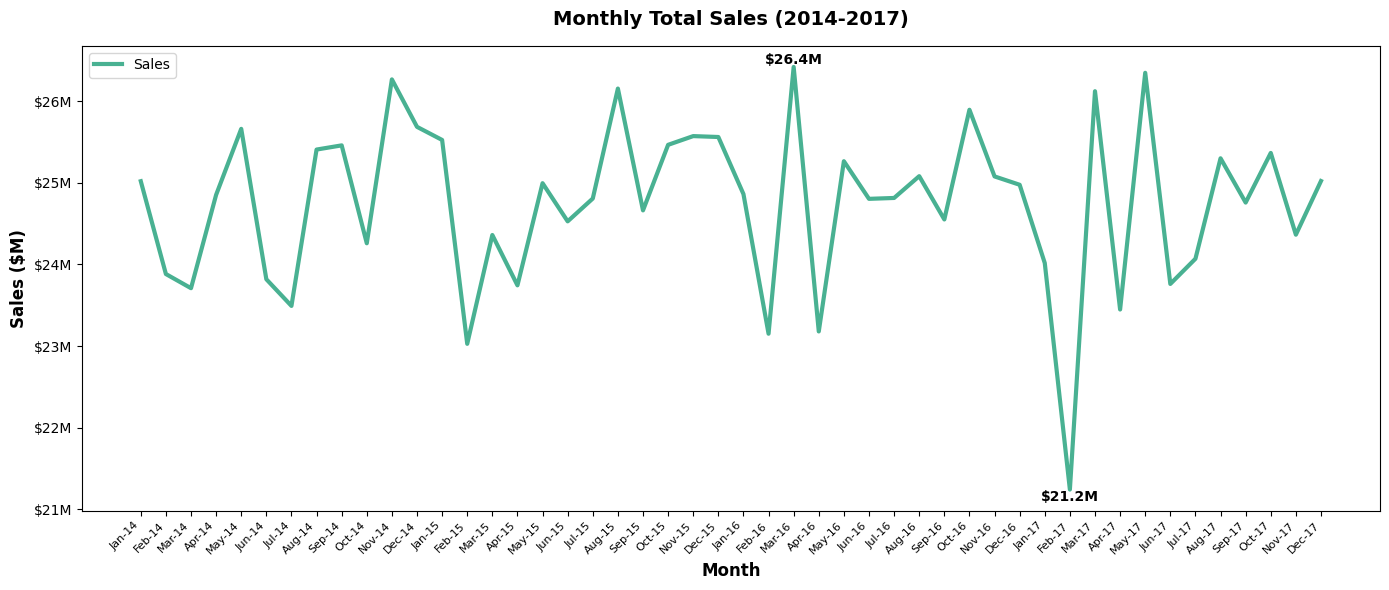

In [ ]:
# Derive Month-Year from OrderDate
df_SalesOrders['Month-Year'] = pd.to_datetime(df_SalesOrders['OrderDate']).dt.to_period('M')

# Aggregate Sales by Month-Year
monthly_data = df_SalesOrders.groupby('Month-Year')['Line Total'].sum().reset_index()

# Convert Month-Year to string in MMM-YY format (e.g., Jan-14)
monthly_data['Month-Year'] = monthly_data['Month-Year'].apply(lambda x: x.strftime('%b-%y'))

# Create a line chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot Sales
ax.plot(monthly_data['Month-Year'], monthly_data['Line Total'], label='Sales', color='#1b9e77', linewidth=3, alpha=0.8)

# Find highest and lowest Sales months
max_sales_idx = monthly_data['Line Total'].idxmax()
min_sales_idx = monthly_data['Line Total'].idxmin()
max_sales = monthly_data.loc[max_sales_idx, 'Line Total']
min_sales = monthly_data.loc[min_sales_idx, 'Line Total']
max_month = monthly_data.loc[max_sales_idx, 'Month-Year']
min_month = monthly_data.loc[min_sales_idx, 'Month-Year']

# Add labels for highest and lowest Sales
ax.text(max_sales_idx, max_sales, f"${max_sales/1_000_000:,.1f}M", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.text(min_sales_idx, min_sales, f"${min_sales/1_000_000:,.1f}M", ha='center', va='top', fontsize=10, fontweight='bold')

# Customize the plot
ax.set_title('Monthly Total Sales (2014-2017)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales ($M)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

# Format y-axis as $M (millions)
def currency_millions_formatter(x, pos):
    return f"${x/1_000_000:,.0f}M"
ax.yaxis.set_major_formatter(FuncFormatter(currency_millions_formatter))

# Set x-axis ticks and labels for every month
all_months = monthly_data['Month-Year']
ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months, rotation=45, ha='right', fontsize=8)

# Add grid for better readability
plt.tight_layout()
plt.show()



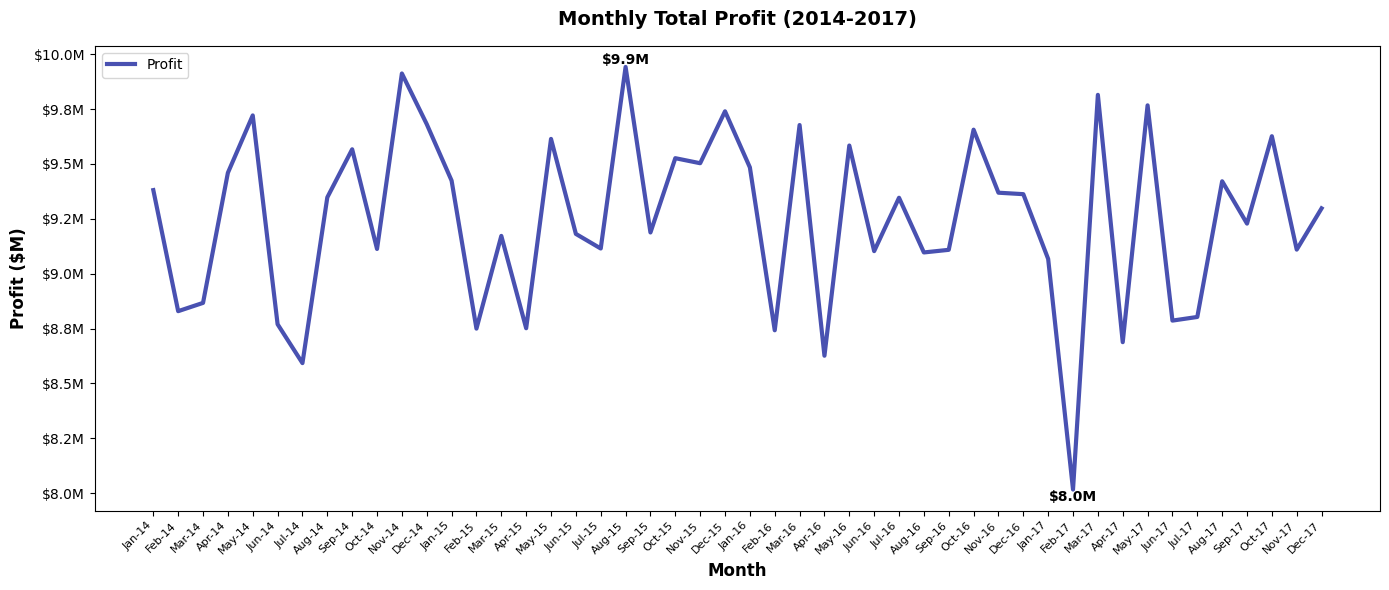

In [ ]:
# Derive Month-Year from OrderDate
df_SalesOrders['Month-Year'] = pd.to_datetime(df_SalesOrders['OrderDate']).dt.to_period('M')

# Aggregate Sales by Month-Year
monthly_data = df_SalesOrders.groupby('Month-Year')['Profit'].sum().reset_index()

# Convert Month-Year to string in MMM-YY format (e.g., Jan-14)
monthly_data['Month-Year'] = monthly_data['Month-Year'].apply(lambda x: x.strftime('%b-%y'))

# Create a line chart
fig, ax = plt.subplots(figsize=(14, 6))

# Plot Profit
ax.plot(monthly_data['Month-Year'], monthly_data['Profit'], label='Profit', color="#1b269e", linewidth=3, alpha=0.8)

# Find highest and lowest Profit months
max_profit_idx = monthly_data['Profit'].idxmax()
min_profit_idx = monthly_data['Profit'].idxmin()
max_profit = monthly_data.loc[max_profit_idx, 'Profit']
min_profit = monthly_data.loc[min_profit_idx, 'Profit']
max_month = monthly_data.loc[max_profit_idx, 'Month-Year']
min_month = monthly_data.loc[min_profit_idx, 'Month-Year']

# Add labels for highest and lowest Profit
ax.text(max_profit_idx, max_profit, f"${max_profit/1_000_000:,.1f}M", ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.text(min_profit_idx, min_profit, f"${min_profit/1_000_000:,.1f}M", ha='center', va='top', fontsize=10, fontweight='bold')

# Customize the plot
ax.set_title('Monthly Total Profit (2014-2017)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Profit ($M)', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')

# Format y-axis as $M (millions) with one decimal place
def currency_millions_formatter(x, pos):
    return f"${x/1_000_000:,.1f}M"
ax.yaxis.set_major_formatter(FuncFormatter(currency_millions_formatter))

# Set x-axis ticks and labels for every month
all_months = monthly_data['Month-Year']
ax.set_xticks(range(len(all_months)))
ax.set_xticklabels(all_months, rotation=45, ha='right', fontsize=8)

# Adjust layout to prevent clipping & add grid for better readability
plt.tight_layout()
plt.show()

In [2442]:
if 'Month-Year' in df_SalesOrders.columns:
    df_SalesOrders.drop(columns='Month-Year', inplace=True, errors='ignore')

In [2443]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61626 entries, 0 to 61625
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   OrderDate                   61626 non-null  datetime64[ns]
 1   Year                        61626 non-null  int32         
 2   Season                      61626 non-null  object        
 3   Channel                     61626 non-null  object        
 4   Product (SKU)               61626 non-null  object        
 5   Order Quantity              61626 non-null  int64         
 6   Unit Price                  61626 non-null  float64       
 7   Line Total                  61626 non-null  float64       
 8   Total Unit Cost             61626 non-null  float64       
 9   Total Cost Per Transaction  61626 non-null  float64       
 10  Profit                      61626 non-null  float64       
 11  Customer Name               61626 non-null  object        


<Figure size 1000x600 with 0 Axes>

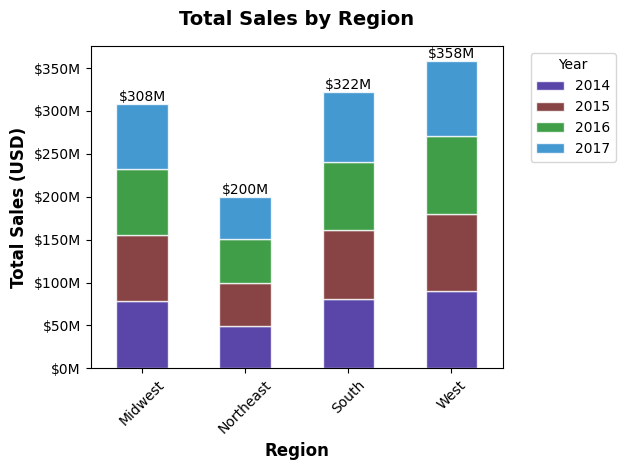

In [2444]:
# Aggregate Sales by Region and Year
sales_by_region_year = df_SalesOrders.groupby(['Region', 'Year'])['Line Total'].sum().unstack()

# Create a stacked bar chart
plt.figure(figsize=(10, 6))
bars = sales_by_region_year.plot(kind='bar', stacked=True, color=["#311894", "#6b1515", "#10861c", "#1580c6", "#293818"], edgecolor='white', alpha=0.8)

# Customize the plot
plt.title('Total Sales by Region', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales (USD)', fontsize=12, fontweight='bold')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Format y-axis as $M (millions)
def currency_millions_formatter(x, pos):
    return f"${x/1_000_000:,.0f}M"
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_millions_formatter))

# Add total sales labels on top of each bar
for i, (region, row) in enumerate(sales_by_region_year.iterrows()):
    total_sales = row.sum()
    formatted_total = f"${total_sales / 1_000_000:,.0f}M"
    plt.text(i, total_sales, formatted_total, ha='center', va='bottom', fontsize=10)

# Add grid for better readability
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

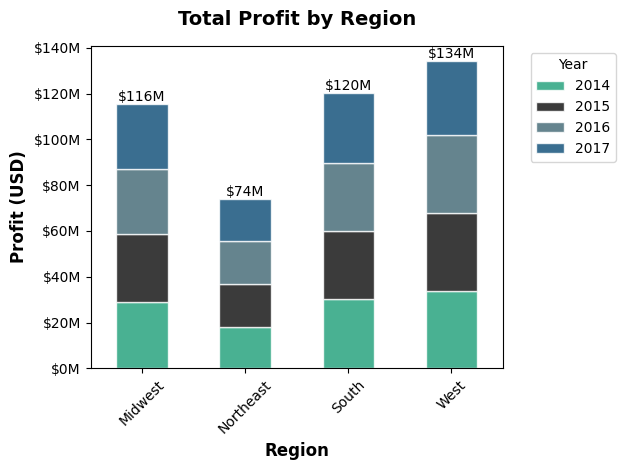

In [2445]:
# Aggregate Profit by Region and Year
profit_by_region_year = df_SalesOrders.groupby(['Region', 'Year'])['Profit'].sum().unstack()

# Create a stacked bar chart
plt.figure(figsize=(10, 6))
profit_by_region_year.plot(kind='bar', alpha=0.8, stacked=True, color=['#1b9e77', "#0a0a0a", "#3f6572", "#094a75", "#293818"], edgecolor='white')

# Customize the plot
plt.title('Total Profit by Region', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Region', fontsize=12, fontweight='bold')
plt.ylabel('Profit (USD)', fontsize=12, fontweight='bold')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Format y-axis as $M (millions)
from matplotlib.ticker import FuncFormatter
def currency_millions_formatter(x, pos):
    return f"${x/1_000_000:,.0f}M"
plt.gca().yaxis.set_major_formatter(FuncFormatter(currency_millions_formatter))

# Add total profit labels on top of each bar
for i, (region, row) in enumerate(profit_by_region_year.iterrows()):
    total_profit = row.sum()
    formatted_total = f"${total_profit / 1_000_000:,.0f}M"
    plt.text(i, total_profit, formatted_total, ha='center', va='bottom', fontsize=10)

# Add grid for better readability
plt.tight_layout()
plt.show()


Seasonal Analysis
- Create bivariate bar chart to show Revenue and Profit broken out by season 
- Create univariate pie chart to show Order Quantity by Season from 2014-2017

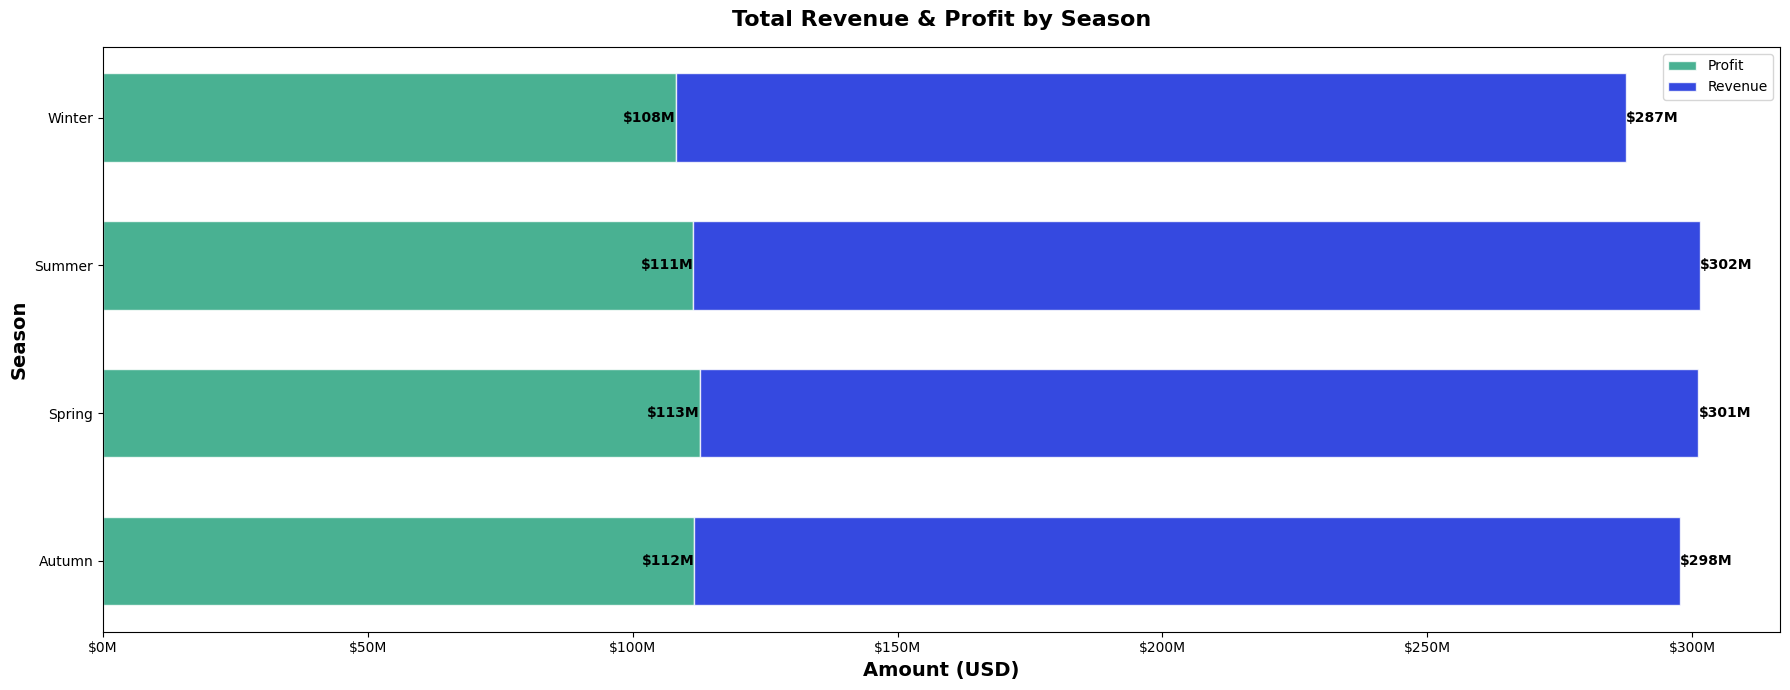

In [2446]:
# Aggregate Sales and Profit by Season
sales_profit_by_season = df_SalesOrders.groupby('Season')[['Line Total', 'Profit']].sum().reset_index()

# Calculate Total Cost Per Transaction by Season
sales_profit_by_season['Total Cost Per Transaction'] = sales_profit_by_season['Line Total'] - sales_profit_by_season['Profit']

# Create a horizontal stacked bar chart
plt.figure(figsize=(18, 7))
bar_height = 0.6
y = np.arange(len(sales_profit_by_season))
plt.barh(y, sales_profit_by_season['Profit'], bar_height, label='Profit', color='#1b9e77', edgecolor='white', alpha=0.8)
plt.barh(y, sales_profit_by_season['Total Cost Per Transaction'], bar_height, left=sales_profit_by_season['Profit'], label='Revenue', color="#021bd9", edgecolor='white', alpha=0.8)

plt.title('Total Revenue & Profit by Season', fontsize=16, pad=15, fontweight='bold')
plt.ylabel('Season', fontsize=14, fontweight='bold')
plt.xlabel('Amount (USD)', fontsize=14, fontweight='bold')
plt.yticks(y, sales_profit_by_season['Season'])
plt.legend()

def currency_millions_formatter(x, pos):
    return f"${x/1_000_000:,.0f}M"
plt.gca().xaxis.set_major_formatter(FuncFormatter(currency_millions_formatter))

for i, row in sales_profit_by_season.iterrows():
    total_sales = row['Line Total']
    profit = row['Profit']
    plt.text(total_sales, i, f"${total_sales/1_000_000:,.0f}M", ha='left', va='center', fontsize=10, fontweight='bold')
    plt.text(profit, i, f"${profit/1_000_000:,.0f}M", ha='right', va='center', fontsize=10, fontweight='bold')  # CHANGED: Added Profit labels

plt.tight_layout()
plt.show()

In [2447]:
# Comparison Calculation of the Profit by Season to ensure the values are correct
profit_by_season = df_SalesOrders.groupby('Season')['Profit'].sum().reset_index()
profit_by_season['Profit ($M)'] = profit_by_season['Profit'].apply(lambda x: f"${x/1_000_000:,.1f}M")
print(profit_by_season)


   Season        Profit Profit ($M)
0  Autumn  1.116510e+08     $111.7M
1  Spring  1.126348e+08     $112.6M
2  Summer  1.114660e+08     $111.5M
3  Winter  1.081665e+08     $108.2M


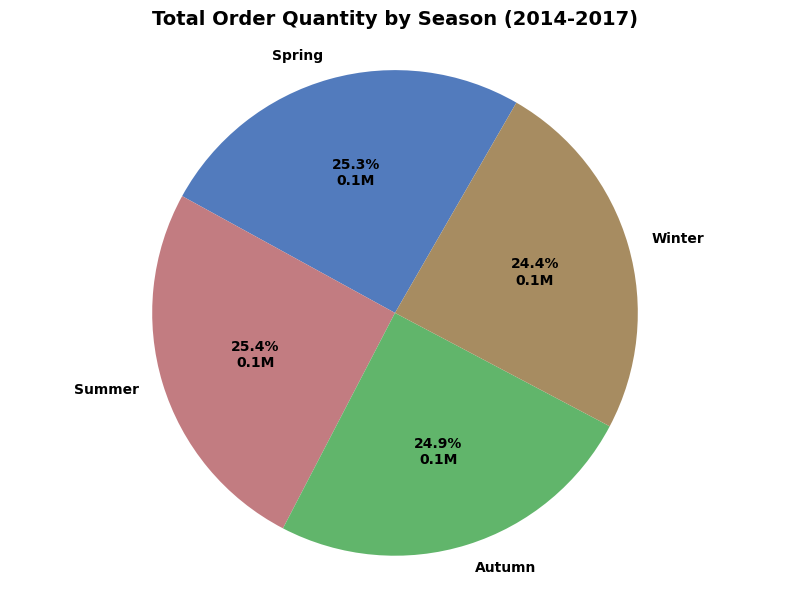

In [2557]:
# Aggregate Order Quantity by Season for 2014-2017
season_data = df_SalesOrders.groupby('Season')['Order Quantity'].sum().reset_index()

# Ensure order of seasons
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_data = season_data.set_index('Season').reindex(season_order).reset_index()

# Prepare data for plotting
quantities = season_data['Order Quantity']
labels = season_data['Season']
colors = ["#527BBD", "#c27c81", "#61B56B", "#A78C61"]

# Create pie chart
fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    quantities,
    labels=labels,
    colors=colors,
    autopct=lambda x: f'{x:.1f}%\n{(x/100 * quantities.sum()/1_000_000):.1f}M',
    startangle=60,
    textprops={'fontsize': 10, 'fontweight': 'bold'})

# Customize the plot
ax.set_title('Total Order Quantity by Season (2014-2017)', fontsize=14, pad=15, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular

# Adjust layout
plt.tight_layout()
plt.show()

Top Products (SKUs)
- Compare the top 5 Products (SKUs) by Revenue, Profit, Orders, and Price

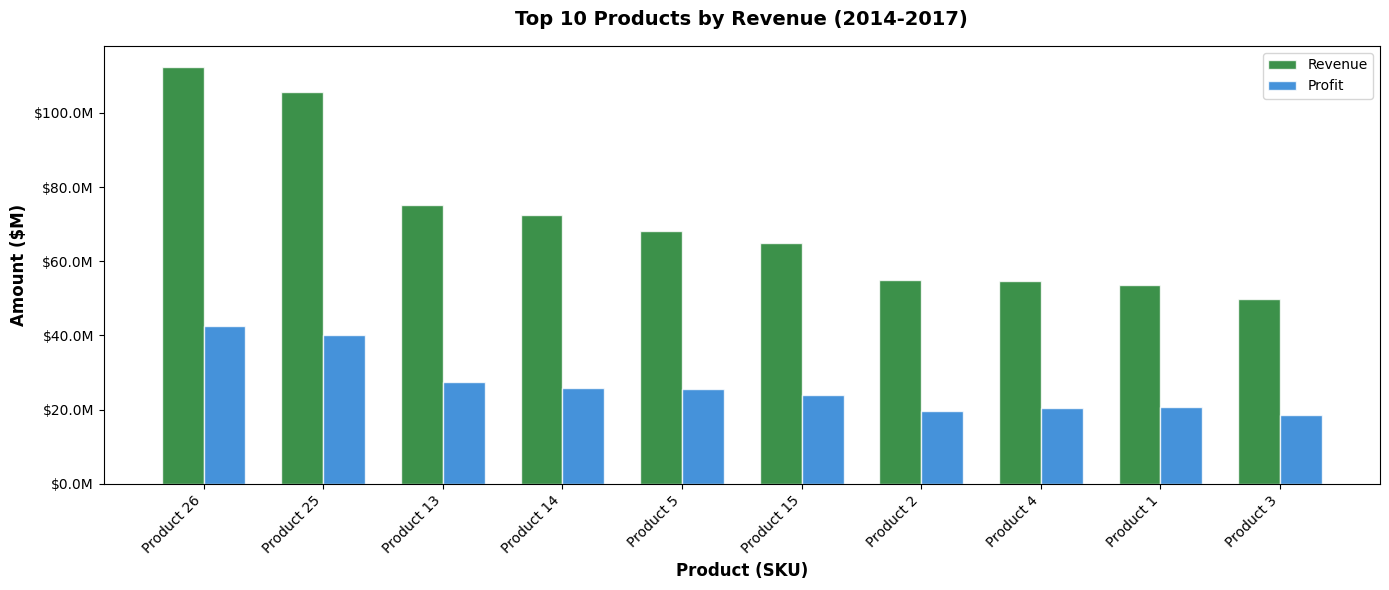

In [2558]:
# Aggregate data by Product (SKU) for 2014-2017
product_data = df_SalesOrders.groupby('Product (SKU)')[['Line Total', 'Profit']].sum().reset_index()

# Select top 10 products by Line Total
top_10_products = product_data.nlargest(10, 'Line Total')

# Prepare data for plotting
products = top_10_products['Product (SKU)']
revenue = top_10_products['Line Total']
profit = top_10_products['Profit']

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
bar_width = 0.35
index = np.arange(len(products))

# Plot two bars per product
ax.bar(index, revenue, bar_width, label='Revenue', color="#0b761d", alpha=0.8, edgecolor='white')
ax.bar(index + bar_width, profit, bar_width, label='Profit', color="#1677d1", alpha=0.8, edgecolor='white')

# Customize the plot
ax.set_title('Top 10 Products by Revenue (2014-2017)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Product (SKU)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount ($M)', fontsize=12, fontweight='bold')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(products, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right')

# Format y-axis as $M with one decimal place
def currency_millions_formatter(x, pos):
    return f"${x/1_000_000:,.1f}M"
ax.yaxis.set_major_formatter(FuncFormatter(currency_millions_formatter))

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

Channel Distribution Comparison 
- Create pie chart showing breakdown of total revenue per channel
- Create pie chart showing breakdown of total profit per channel 

In [2559]:
df_SalesOrders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61626 entries, 0 to 61625
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   OrderDate                   61626 non-null  datetime64[ns]
 1   Year                        61626 non-null  int32         
 2   Season                      61626 non-null  object        
 3   Channel                     61626 non-null  object        
 4   Product (SKU)               61626 non-null  object        
 5   Order Quantity              61626 non-null  int64         
 6   Unit Price                  61626 non-null  float64       
 7   Line Total                  61626 non-null  float64       
 8   Total Unit Cost             61626 non-null  float64       
 9   Total Cost Per Transaction  61626 non-null  float64       
 10  Profit                      61626 non-null  float64       
 11  Customer Name               61626 non-null  object        


In [2560]:
df_SalesOrders.head(5)

,OrderDate,Year,Season,Channel,Product (SKU),Order Quantity,Unit Price,Line Total,Total Unit Cost,Total Cost Per Transaction,Profit,Customer Name,City,State Code,State,Region,2017 Budgets
0,2014-01-01,2014,Winter,Wholesale,Product 27,6,2499.1,14994.6,1824.343,10946.058,4048.542,Rhynoodle Ltd,Savannah,GA,Georgia,South,964940.231
1,2014-01-01,2014,Winter,Distributor,Product 20,11,2351.7,25868.7,1269.918,13969.098,11899.602,Thoughtmix Ltd,Greenwood,IN,Indiana,Midwest,2067108.120
2,2014-01-01,2014,Winter,Wholesale,Product 26,6,978.2,5869.2,684.740,4108.440,1760.760,Amerisourc Corp,Pleasanton,CA,California,West,5685138.270
3,2014-01-01,2014,Winter,Export,Product 7,7,2338.3,16368.1,1028.852,7201.964,9166.136,Colgate-Pa Group,Bloomington,IN,Indiana,Midwest,889737.555
4,2014-01-01,2014,Winter,Wholesale,Product 8,8,2291.4,18331.2,1260.270,10082.160,8249.040,Deseret Group,Manchester,CT,Connecticut,Northeast,1085037.329
